In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%reload_ext autoreload
%autoreload 2

print("cwd:", Path.cwd())
print("sys.path:", sys.path[:5])

from src.config import SimulationConfig
from src.parameters import CBCParameters
from src.sampling import ParameterSampler
from src.injection import SignalInjector

cwd: /home/victor/gw/cbc_pe/notebooks
sys.path: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '']


## SimulationConfig

In [2]:
config = SimulationConfig()

print("sampling_frequency (Hz):", config.sampling_frequency)
print("duration (s):", config.duration)
print("delta_t (s):", config.delta_t)
print("length:", config.length)
print("delta_f (Hz):", config.delta_f)
print("flength:", config.flength)

sampling_frequency (Hz): 4096.0
duration (s): 4.0
delta_t (s): 0.000244140625
length: 16384
delta_f (Hz): 0.25
flength: 8193


## CBCParameters

In [3]:
params = CBCParameters(
    mass_1=20.0,
    mass_2=40.0,
    distance=500.0,
    inclination=np.pi / 3,
    ra=1.2,
    dec=0.4,
    spin_1z=0.3,
    spin_2z=-0.2,
)

print(params)
print("mass_1 (Msun):", params.mass_1)
print("mass_2 (Msun):", params.mass_2)
print("total_mass (Msun):", params.total_mass)
print("chirp_mass (Msun):", params.chirp_mass)
print("chi_eff:", params.chi_eff)

CBCParameters(mass_1=40.0, mass_2=20.0, distance=500.0, inclination=1.0471975511965976, ra=1.2, dec=0.4, spin_1z=-0.2, spin_2z=0.3)
mass_1 (Msun): 40.0
mass_2 (Msun): 20.0
total_mass (Msun): 60.0
chirp_mass (Msun): 24.334573675728226
chi_eff: -0.03333333333333333


## ParameterSampler

In [4]:
sampler = ParameterSampler(rng=np.random.default_rng(42))
samples = sampler.sample_many(50000)

print(type(samples[0]))
print(samples[0])

mass_1 = np.array([s.mass_1 for s in samples])
mass_2 = np.array([s.mass_2 for s in samples])
inclinations = np.array([s.inclination for s in samples])
ras = np.array([s.ra for s in samples])
decs = np.array([s.dec for s in samples])

print(np.all(mass_1 >= mass_2))
print(ras.min(), ras.max())
print(decs.min(), decs.max())
print(inclinations.min(), inclinations.max())

<class 'src.parameters.CBCParameters'>
CBCParameters(mass_1=70.78626412725689, mass_2=42.30466737892445, distance=4321.270015574636, inclination=np.float64(1.1650157632181057), ra=0.5917337285168199, dec=np.float64(1.2572466191009846), spin_1z=0.5222794039807059, spin_2z=0.5721286105539076)
True
2.9236616297589228e-05 6.283080156358749
-1.5558382454793735 1.5634006339527045
0.009587441437286907 3.1304001449481835


### Isotropic checks for cos(i) and sin(dec)

<>:7: SyntaxWarning: invalid escape sequence '\i'
<>:7: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_2584/1952523643.py:7: SyntaxWarning: invalid escape sequence '\i'
  ax[0].set_title(f"cos($\iota$)")


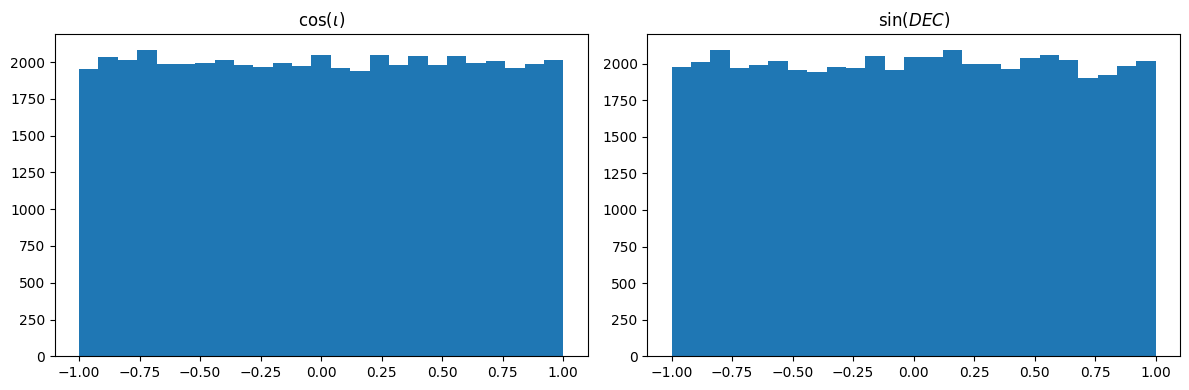

In [5]:
cos_i = np.cos(inclinations)
sin_dec = np.sin(decs)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(cos_i, bins=25)
ax[0].set_title(f"cos($\iota$)")

ax[1].hist(sin_dec, bins=25)
ax[1].set_title(f"sin($\tDEC$)")

plt.tight_layout()
plt.show()

## SignalInjector

InjectionResult(strain=<pycbc.types.timeseries.TimeSeries object at 0x7fb425f31370>, injection_time=np.float64(1.093505859375), injection_index=np.int64(4479))


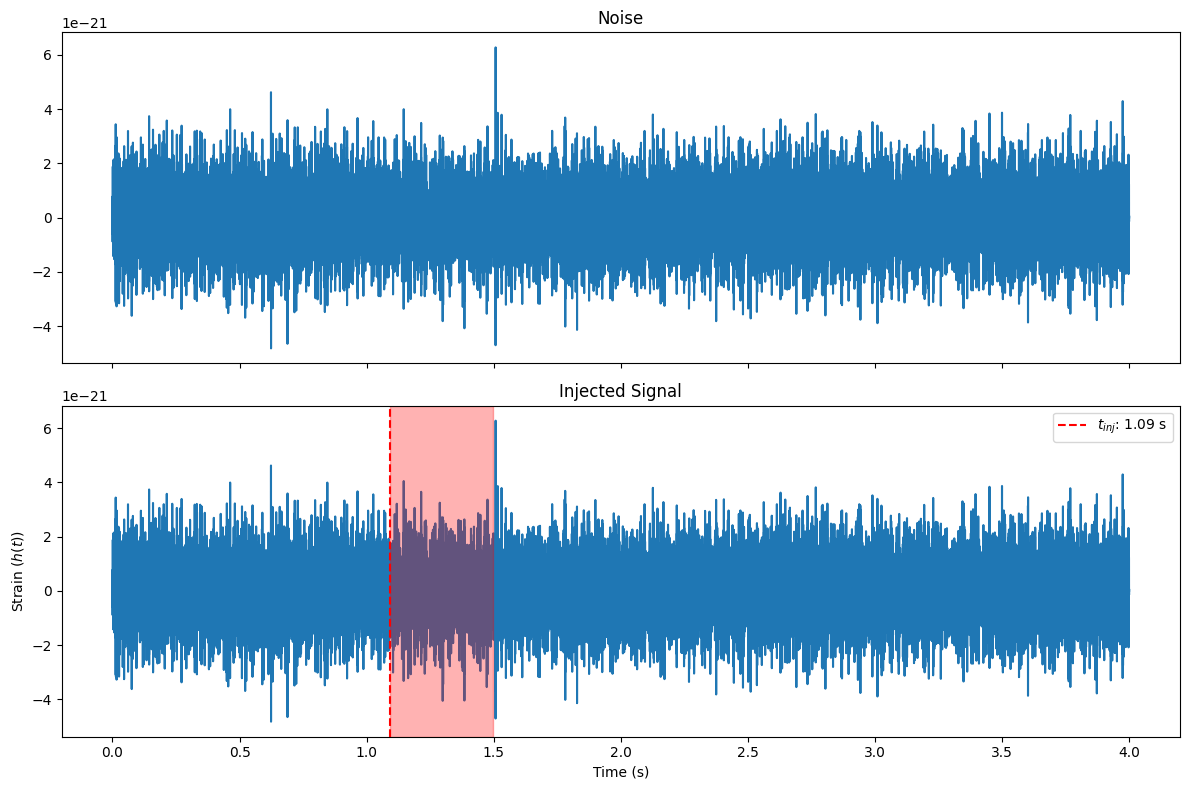

In [6]:
from src.noise import NoiseModel
from src.waveform import WaveformGenerator
from src.detectors import DetectorProjector

import lal as _lal

noise_model = NoiseModel(config=config)
noise = noise_model.sample(detector_name="V1")

waveform_generator = WaveformGenerator(config=config)
hp, hc = waveform_generator.generate(parameters=params)

detector_projector = DetectorProjector()
projected_signal = detector_projector.project(h_plus=hp, h_cross=hc, parameters=params)

signal_injector = SignalInjector(config=config)
injected_signal = signal_injector.inject(strain=noise, signal=projected_signal["V1"])

############### PLOTTING ###############

print(injected_signal)
t = np.arange(config.length) * config.delta_t

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, noise)   
ax[0].set_title("Noise")


ax[1].plot(t, injected_signal.strain)
ax[1].set_title("Injected Signal")
# Band with the duration of the signal above the injected signal plot
ax[1].axvspan(
    injected_signal.injection_time,
    injected_signal.injection_time + len(projected_signal["V1"])*projected_signal["V1"].delta_t,
    color='red',
    alpha=0.3,
    zorder=2)
ax[1].axvline(injected_signal.injection_time, color='red', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()



## SignalProcessor

In [7]:
from src.processing import SignalProcessor

processor = SignalProcessor(
    config=config,
    apply_whitening=True,
    apply_lowpass=True,
    apply_highpass=True,
    apply_standardization=True,
    preserve_length=True,
    lowpass_frequency=350.0,
    highpass_frequency=30.0,
)



processed_signal = processor.process(injected_signal.strain)
print(type(processed_signal))
print(len(injected_signal.strain), len(processed_signal))
print("injected_signal.delta_f:",injected_signal.strain.delta_f)
print("injected_signal.delta_t:",injected_signal.strain.delta_t)
print("processed_signal.delta_f:",processed_signal.delta_f)
print("processed_signal.duration:",processed_signal.duration)
print("injected_signal.strain.duration:",injected_signal.strain.duration)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("crop left time:", processed_signal.start_time - injected_signal.strain.start_time)

left_crop_samples = int(((processed_signal.start_time - injected_signal.strain.start_time) / processed_signal.delta_t))
print("left_crop_samples:", left_crop_samples)

print("original start_time:", injected_signal.strain.start_time)
print("processed start_time:", processed_signal.start_time)
print("original length:", len(injected_signal.strain))
print("processed length:", len(processed_signal))



<class 'pycbc.types.timeseries.TimeSeries'>
16384 16384
injected_signal.delta_f: 0.25
injected_signal.delta_t: 0.000244140625
processed_signal.delta_f: 0.25
processed_signal.duration: 4.0
injected_signal.strain.duration: 4.0
original start_time: 0
processed start_time: 0
crop left time: 0
left_crop_samples: 0
original start_time: 0
processed start_time: 0
original length: 16384
processed length: 16384


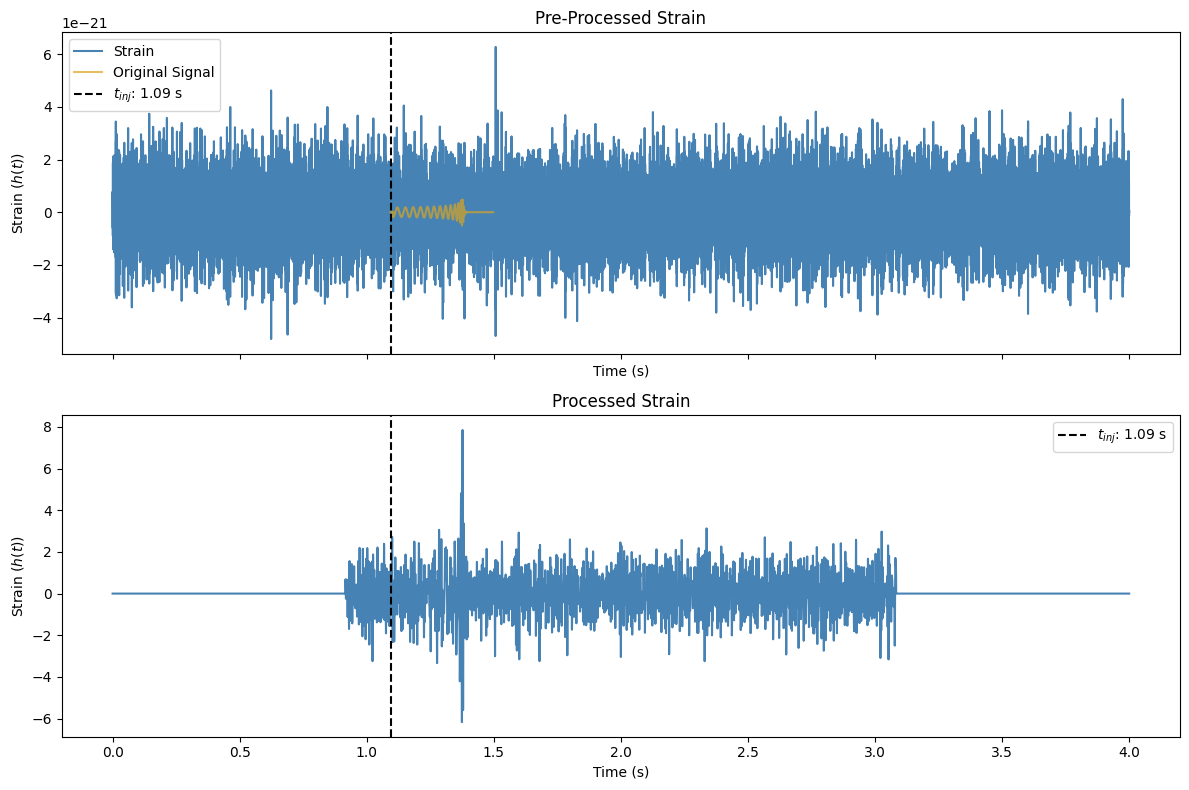

In [8]:
############### PLOTTING ###############

t = np.arange(config.length) * config.delta_t
t_processed = np.arange(len(processed_signal)) * processed_signal.delta_t + processed_signal.start_time
t_projected = np.arange(len(projected_signal["V1"])) * projected_signal["V1"].delta_t + injected_signal.injection_time

# plot the noise, signal, and injected signal
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t, injected_signal.strain, color='steelblue', label="Strain")  
ax[0].plot(t_projected, projected_signal["V1"], color='goldenrod', linestyle='-', alpha=0.7, label="Original Signal") 
ax[0].set_title("Pre-Processed Strain")
ax[0].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Strain ($h(t)$)")
ax[0].legend()

ax[1].plot(t_processed, processed_signal, color='steelblue')
ax[1].set_title("Processed Strain")
ax[1].axvline(injected_signal.injection_time, color='k', linestyle='--', label=f"$t_{{inj}}$: {injected_signal.injection_time:.2f} s", zorder=3)
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("Strain ($h(t)$)")
ax[1].legend()

# Vertical line at the injection time
plt.tight_layout()
plt.show()
plt.close()

## Generating one-sample

In [9]:
from src.config import SimulationConfig
from src.dataset import DatasetBuilder

config = SimulationConfig()
builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
        lowpass_frequency=350.0,
        highpass_frequency=30.0,
    ),
)

sample = builder.build_sample()

print(type(builder))
print(sample.X.shape)
print(sample.y.shape)
print(sample.parameters)
print(type(sample.parameters))


# Check if signal processor arguments are correctly applied
builder = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=False,
        preserve_length=True,
    ),
)

print(builder.signal_processor.apply_whitening)
print(builder.signal_processor.apply_lowpass)
print(builder.signal_processor.apply_highpass)
print(builder.signal_processor.preserve_length)


# Check if label transformer arguments are correctly applied
mean = np.array([10.0, 20.0, 0.0])
std = np.array([2.0, 5.0, 0.5])

builder = DatasetBuilder.from_config(
    config=config,
    label_transformer_kwargs=dict(mean=mean, std=std),
)

print(builder.label_transformer.mean)
print(builder.label_transformer.std)

# Check if preserve ordering of detectors name
builder = DatasetBuilder.from_config(
    config=config,
    detector_names=["V1", "H1"],
    signal_processor_kwargs=dict(preserve_length=True),
)

print(builder.detector_names)

sample = builder.build_sample()
print(sample.X.shape)

<class 'src.dataset.DatasetBuilder'>
(3, 16384)
(3,)
CBCParameters(mass_1=39.15564849078147, mass_2=32.47664083879526, distance=1287.089489681803, inclination=np.float64(2.808225676821131), ra=5.582570872606636, dec=np.float64(0.5666791032009607), spin_1z=0.44605949557278746, spin_2z=-0.970685514936525)
<class 'src.parameters.CBCParameters'>
True
True
False
True
[10. 20.  0.]
[2.  5.  0.5]
['V1', 'H1']
(2, 16384)


In [10]:
# Check for reproducibility with rng
rng1 = np.random.default_rng(123)
rng2 = np.random.default_rng(123)

builder1 = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
    ),
    rng=rng1,
)

builder2 = DatasetBuilder.from_config(
    config=config,
    signal_processor_kwargs=dict(
        apply_whitening=True,
        apply_lowpass=True,
        apply_highpass=True,
        apply_standardization=True,
        preserve_length=True,
    ),
    rng=rng2,
)

sample1 = builder1.build_sample()
sample2 = builder2.build_sample()

print(np.allclose(sample1.X, sample2.X))  #The noise introduced doesnt include a seed, all other physical parameters are reproducible
print(np.allclose(sample1.y, sample2.y))
print(sample1.parameters == sample2.parameters)

False
True
True


## ... and multiple samples

In [11]:
batch = builder.build_dataset(num_samples=10)

print(batch.X.shape)
print(batch.y.shape)
print(batch.parameters[0])
print(len(batch.parameters))
print(type(batch.parameters[0]))

(10, 2, 16384)
(10, 3)
CBCParameters(mass_1=59.731991553706294, mass_2=24.381505341207856, distance=607.309172393739, inclination=np.float64(1.8913720289435902), ra=2.153853492410293, dec=np.float64(-0.31472562578503566), spin_1z=-0.29835859842707646, spin_2z=-0.12861320596771808)
10
<class 'src.parameters.CBCParameters'>


### TO DO LIST:
- Implementar una configuracion en la que se puede generar la dataset en un intervalo SNR reajustando consecuentemente la distancia (como el trabajo original)
- Decidir que tipo de input uso para la NN. 
    - Originalmente, CNN pero dando time-series. Si uso TS podría mirar otro tipo de arquitecturas mejor que CNN, quizá TCN (temporal), RNN o LSTMs. (MQRNN ?)
    - Quizá un spectrogtama con CNN podría ser más efectivo, o explorar otras arquitecturas. (NODE ? :  https://arxiv.org/abs/1806.07366)

# Mondrian (conformal binning) implementation example

In [3]:
import numpy as np
import random

from src.conformal.binning import PredictionBinner, BinGrouper
from src.conformal.calibration import ConformalIntervalCalibrator
from src.conformal.apply import apply
from src.conformal.metrics import CoverageEvaluator

rng = np.random.default_rng(42)

# =========================
# 1) Synthetic calibration and test data
# =========================
n_cal = 400
n_test = 200
n_labels = 3

# True values for calibration
y_cal = np.column_stack([
    rng.normal(loc=25.0, scale=5.0, size=n_cal),    # chirp-like
    rng.normal(loc=60.0, scale=10.0, size=n_cal),   # total-mass-like
    rng.normal(loc=0.0, scale=0.3, size=n_cal),     # chi_eff-like
])

# Heteroscedastic noise: error depends a bit on the true value
cal_noise = np.column_stack([
    rng.normal(0.0, 0.8 + 0.03 * np.abs(y_cal[:, 0]), size=n_cal),
    rng.normal(0.0, 1.5 + 0.02 * np.abs(y_cal[:, 1]), size=n_cal),
    rng.normal(0.0, 0.05 + 0.10 * np.abs(y_cal[:, 2]), size=n_cal),
])

# Predictions are truth plus noise
pred_cal = y_cal + cal_noise

# Residuals in the convention y_true - y_pred
residuals_cal = y_cal - pred_cal

# Test data
y_test = np.column_stack([
    rng.normal(loc=25.0, scale=5.0, size=n_test),
    rng.normal(loc=60.0, scale=10.0, size=n_test),
    rng.normal(loc=0.0, scale=0.3, size=n_test),
])

test_noise = np.column_stack([
    rng.normal(0.0, 0.8 + 0.03 * np.abs(y_test[:, 0]), size=n_test),
    rng.normal(0.0, 1.5 + 0.02 * np.abs(y_test[:, 1]), size=n_test),
    rng.normal(0.0, 0.05 + 0.10 * np.abs(y_test[:, 2]), size=n_test),
])

pred_test = y_test + test_noise

print("pred_cal shape:", pred_cal.shape)
print("y_cal shape:", y_cal.shape)
print("residuals_cal shape:", residuals_cal.shape)
print("pred_test shape:", pred_test.shape)
print("y_test shape:", y_test.shape)





pred_cal shape: (400, 3)
y_cal shape: (400, 3)
residuals_cal shape: (400, 3)
pred_test shape: (200, 3)
y_test shape: (200, 3)


In [13]:
# =========================
# 2) Mondrian pipeline
# =========================
n_bins = 24

binner = PredictionBinner(
    n_bins=n_bins,
    rng=np.random.default_rng(123),
    apply_jitter=True,
    jitter_variation=1e-10,
)

bin_indices_cal = binner.fit_transform(pred_cal)

grouper = BinGrouper(n_bins=n_bins)
grouped_residuals = grouper.group_by_bin(residuals_cal, bin_indices_cal)

calibrator = ConformalIntervalCalibrator(
    confidence_level=0.90,
    interval_mode="symmetric",
)
calibrator.fit(grouped_residuals)

bin_indices_test = binner.transform(pred_test)

lower, upper = apply(
    predictions=pred_test,
    bin_indices=bin_indices_test,
    intervals=calibrator.intervals_,
)

evaluator = CoverageEvaluator()
metrics = evaluator.evaluate(
    y=y_test,
    upper_bound=upper,
    lower_bound=lower,
    bin_indices=bin_indices_test,
)

print("bin_indices_cal shape:", bin_indices_cal.shape)
print("grouped_residuals shape:", grouped_residuals.shape)
print("intervals shape:", calibrator.intervals_.shape)
print("bin_indices_test shape:", bin_indices_test.shape)
print("lower shape:", lower.shape)
print("upper shape:", upper.shape)

bin_indices_cal shape: (400, 3)
grouped_residuals shape: (3, 24)
intervals shape: (3, 24, 2)
bin_indices_test shape: (200, 3)
lower shape: (200, 3)
upper shape: (200, 3)


In [11]:
# =========================
# 3) Main metrics
# =========================
print("Global coverage:", metrics["global_coverage"])
print("Miscoverage:", metrics["miscoverage"])
print("Global mean width:", metrics["global_mean_width"])
print("Coverage per bin:", None if metrics["coverage_per_bin"] is None else metrics["coverage_per_bin"])
print("Mean width per bin:", None if metrics["mean_width_per_bin"] is None else metrics["mean_width_per_bin"])
print("Counts per bin:", None if metrics["counts_per_bin"] is None else metrics["counts_per_bin"])

Global coverage: [0.965 0.945 0.965]
Miscoverage: [0.035 0.055 0.035]
Global mean width: [ 7.15088911 11.0736465   0.33655746]
Coverage per bin: [[1.         1.         1.        ]
 [1.         0.8        1.        ]
 [0.875      1.         0.92307692]
 [1.         1.         0.81818182]
 [1.         0.92307692 1.        ]
 [1.         1.         0.90909091]
 [1.         1.         1.        ]
 [1.         0.86666667 1.        ]
 [1.         1.         1.        ]
 [1.         1.         1.        ]
 [1.         0.72727273 0.9       ]
 [1.         0.90909091 1.        ]
 [1.         1.         1.        ]
 [0.85714286 1.         1.        ]
 [1.         1.         1.        ]
 [1.         1.         1.        ]
 [1.         1.         0.85714286]
 [0.66666667 1.         1.        ]
 [0.75       1.         1.        ]
 [1.         1.         1.        ]
 [0.88888889 0.875      1.        ]
 [1.         0.92307692 0.90909091]
 [0.85714286 0.91666667 1.        ]
 [1.         1.         1. 

In [12]:
# Optional: readable per-bin display
label_names = [" -- CHIRP_MASS -- ", " -- TOTAL_MASS -- ", " -- CHI_EFF -- "]

for j, name in enumerate(label_names):
    print(f"\n{name}")
    print("global coverage:", metrics["global_coverage"][j])
    print("global mean width:", metrics["global_mean_width"][j])
    print("coverage per bin:", metrics["coverage_per_bin"][:, j])
    print("mean width per bin:", metrics["mean_width_per_bin"][:, j])
    print("counts per bin:", metrics["counts_per_bin"][:, j])


 -- CHIRP_MASS -- 
global coverage: 0.965
global mean width: 7.150889113562926
coverage per bin: [1.         1.         0.875      1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         0.85714286 1.         1.         1.         0.66666667
 0.75       1.         0.88888889 1.         0.85714286 1.        ]
mean width per bin: [ 5.86698747  6.32714616  6.29787178  9.01818482  8.36672707  6.5495927
  9.07656486  6.44465283  8.59220536  7.576662    6.45520901  9.31209363
  5.40061964  4.74779677  6.87269451  5.46281204  7.27408096  7.0615617
  4.69455431  7.92961677  5.31729114  8.42671431  6.47967315 10.02709993]
counts per bin: [12  5  8  4  8  6  3  7  7 18  8  6  2  7 15 10 10  3  4  9  9 10 14 15]

 -- TOTAL_MASS -- 
global coverage: 0.945
global mean width: 11.073646496906607
coverage per bin: [1.         0.8        1.         1.         0.92307692 1.
 1.         0.86666667 1.         1.         0.72727273 0.90909091
 1.         1.         

## Using the pipeline

In [24]:
from src.conformal.pipeline import run_mondrian_regression
results = run_mondrian_regression(
    pred_cal=pred_cal,
    pred_test=pred_test,
    y_cal=y_cal,
    y_test=y_test,
    n_bins=12,
    confidence_level=0.90,
    apply_jitter=True,
)

print(results.intervals.shape)
print(results.lower.shape)
print(results.upper.shape)
print(results.metrics["global_coverage"])

(3, 12, 2)
(200, 3)
(200, 3)
[0.96  0.915 0.92 ]


## Plots (conformal)